# 인공지능수학 3주차 — 교실 실습

**시간:** 75분 | **구성:** 손문제 (35분) + 버그 잡기 (20분) + 코딩 실습 (20분)

**이름:** ___________________ &emsp; **학번:** ___________________

---
## 💡 오늘 영상에서 배운 것
- 선형회귀 모델: $\hat{y} = \mathbf{w}^T\mathbf{x}$
- 잔차: $e_i = y_i - \hat{y}_i$
- MSE: $\mathcal{L} = \frac{1}{m}\sum_i e_i^2 = \frac{1}{m}\|\mathbf{y} - X\mathbf{w}\|^2$
- MSE는 $\mathbf{w}$의 이차함수 → 그릇 모양, 최솟값 하나
- 정규방정식: $\mathbf{w}^* = (X^TX)^{-1}X^T\mathbf{y}$

---
# Part A. 손으로 푸는 문제 (35분)

## 문제 1. 잔차와 MSE 손계산 (10분)

모델 $\hat{y} = 3x + 1$ 에 대해 다음 데이터의 잔차와 MSE를 구하세요.

| $i$ | $x_i$ | $y_i$ | $\hat{y}_i = 3x_i + 1$ | $e_i = y_i - \hat{y}_i$ | $e_i^2$ |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 1 | 1 | 5 | | | |
| 2 | 2 | 8 | | | |
| 3 | 3 | 10 | | | |
| 4 | 4 | 11 | | | |

$$\text{MSE} = \frac{1}{m}\sum_{i=1}^m e_i^2 = \quad ?$$

<br><br><br>

## 문제 2. MSE의 이차함수 구조 (15분)

데이터가 2개일 때 MSE를 $w$의 함수로 나타내고, 최솟값을 구하세요.  
(편향 없음: $\hat{y}_i = wx_i$)

| $i$ | $x_i$ | $y_i$ |
|:---:|:---:|:---:|
| 1 | 2 | 6 |
| 2 | 4 | 10 |

**(1)** MSE를 $w$의 식으로 나타내세요.

$$\mathcal{L}(w) = \frac{1}{2}\left[(6 - 2w)^2 + (10 - 4w)^2\right] = ?$$

<br><br><br><br>

**(2)** 전개한 식에서 $Aw^2 + Bw + C$ 형태로 쓰고 $A$, $B$, $C$를 구하세요.

<br><br><br><br>

**(3)** 이차함수의 꼭짓점 공식 $w^* = -\dfrac{B}{2A}$ 를 이용해 최적 $w$를 구하세요.

<br><br><br>

**(4)** $w^*$일 때 MSE 값을 구하세요.

<br><br><br>

## 문제 3. 정규방정식 (10분)

문제 2의 데이터를 행렬로 표현하고 정규방정식으로 $w^*$를 구하세요.

$$X = \begin{bmatrix} 2 \\ 4 \end{bmatrix}, \quad \mathbf{y} = \begin{bmatrix} 6 \\ 10 \end{bmatrix}$$

**(1)** $X^TX$를 계산하세요. (스칼라가 나옵니다)

<br><br><br>

**(2)** $X^T\mathbf{y}$를 계산하세요.

<br><br><br>

**(3)** $w^* = (X^TX)^{-1}X^T\mathbf{y}$를 계산하세요. 문제 2-(3)의 답과 같나요?

<br><br><br>

---
# Part B. 🐛 팀 버그 잡기 (20분)

2~3명이 함께 분석하세요. 실행 전에 눈으로 먼저 찾고 합의 후 확인하세요.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

### 버그 1. MSE 계산 오류 — 에러는 없지만 결과가 틀림

In [3]:
# 🐛 Bug 1 — runs without error, but gives wrong MSE
y     = np.array([5.0, 8.0, 10.0, 11.0])
y_hat = np.array([4.0, 7.0,  9.0, 11.0])

# Intention: compute MSE
mse = np.sum((y - y_hat) ** 2)   # ← what's wrong?
print(f"MSE = {mse:.4f}")         # should be 0.75, not 3.0

MSE = 3.0000


In [5]:
# ✅ Fix Bug 1
mse_fixed = np.sum((y-y_hat)**2)/y.size
print(f"MSE = {mse_fixed:.2f}")   # expected: 0.75

MSE = 0.75


### 버그 2. 정규방정식 — shape 오류

In [28]:
# 🐛 Bug 2 — shape error in normal equation
x = np.array([2.0, 4.0])
y = np.array([6.0, 10.0])

# Intention: w* = (X^T X)^{-1} X^T y
X = x.reshape(2,1)                            # ← should be a 2D column vector
w_star = np.linalg.inv(X.T @ X) @ X.T @ y
print(f"w* = {w_star[0]:.4f}")

w* = 2.6000


In [ ]:
# ✅ Fix Bug 2
X_fixed = X.reshape(2, 1)             # reshape to (2, 1)
w_star  = np.linalg.inv(X_fixed.T @ X_fixed) @ X_fixed.T @ y
print(f"w* = {w_star[0]:.4f}")   # expected: ~2.5

w* = 2.600000


### 버그 3. 잔차 시각화 — 논리 오류

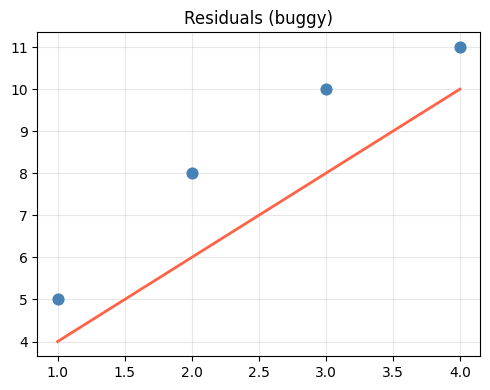

In [10]:
# 🐛 Bug 3 — residual lines are drawn incorrectly
np.random.seed(0)
x_data = np.array([1.0, 2.0, 3.0, 4.0])
y_data = np.array([5.0, 8.0, 10.0, 11.0])
w, b   = 2.0, 2.0
y_pred = w * x_data + b

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x_data, y_data, color='steelblue', s=60, zorder=5)
ax.plot(x_data, y_pred, color='tomato', linewidth=2)

# Intention: draw vertical lines from data point to predicted value
for xi, yi, yhi in zip(x_data, y_data, y_pred):
    ax.plot([xi, xi], [yi, yi],    # ← both endpoints are the same!
            color='gray', linewidth=1.5, linestyle='--')

ax.set_title('Residuals (buggy)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

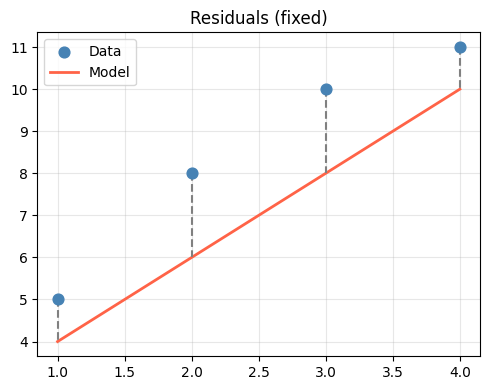

In [13]:
# ✅ Fix Bug 3
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(x_data, y_data, color='steelblue', s=60, zorder=5, label='Data')
ax.plot(x_data, y_pred, color='tomato', linewidth=2, label='Model')

for xi, yi, yhi in zip(x_data, y_data, y_pred):
    ax.plot([xi, xi], [yi, yhi],   # ← fix here
            color='gray', linewidth=1.5, linestyle='--')

ax.set_title('Residuals (fixed)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Part C. 코딩 실습 (20분)

## 실습 1. 손계산 검증 (8분)

In [35]:
# Lab 1: verify hand calculations from Problem 1 and 2
x = np.array([1.0, 2.0, 3.0, 4.0])
y = np.array([5.0, 8.0, 10.0, 11.0])

# Problem 1: model y_hat = 3x + 1
y_hat = 3 * x + 1
mse_p1 = np.sum((y-y_hat)**2)/y.size
print(f"Problem 1 MSE = {mse_p1:.4f}")

# Problem 2~3: optimal w via normal equation (no bias)
x2 = np.array([2.0, 4.0])
y2 = np.array([6.0, 10.0])
X2 = x2.reshape(2, 1)             # shape (2, 1)
w_star = np.linalg.inv(X2.T@X2) @ X2.T@y2                     # normal equation
print(f"Optimal w = {w_star[0]:.4f}")

Problem 1 MSE = 1.5000
Optimal w = 2.6000


## 실습 2. 손실 함수 시각화 (12분)

문제 2의 데이터로 MSE($w$) 그래프를 그리고 최솟값을 표시하세요.

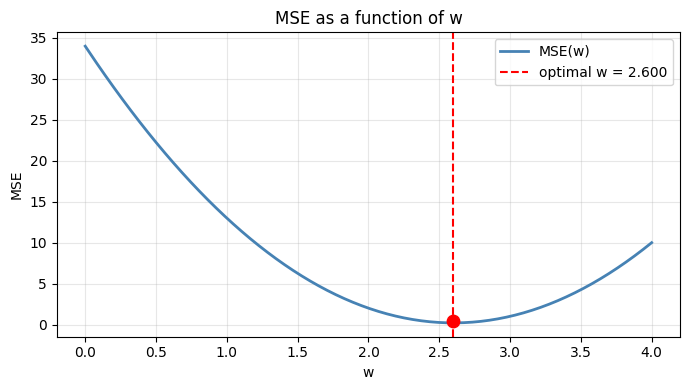

In [41]:
# Lab 2: visualize MSE(w) and mark the minimum
x2 = np.array([2.0, 4.0])
y2 = np.array([6.0, 10.0])

w_range = np.linspace(0, 4, 200)

# TODO: compute MSE for each w value
mse_vals = [np.mean((y2 - w*x2)**2) / y2.size for w in w_range]

# TODO: find optimal w from normal equation
X2     = x2.reshape(-1, 1)
w_star = np.linalg.inv(X2.T @ X2) @ X2.T @ y2
w_opt  = w_star[0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(w_range, mse_vals, color='steelblue', linewidth=2, label='MSE(w)')
ax.axvline(w_opt, color='red', linestyle='--',
           label=f'optimal w = {w_opt:.3f}')
ax.scatter([w_opt], [np.mean((y2 - w_opt * x2)**2)],
           color='red', s=80, zorder=5)
ax.set_xlabel('w')
ax.set_ylabel('MSE')
ax.set_title('MSE as a function of w')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 📋 오늘 실습 체크리스트

- [ ] 잔차표를 채우고 MSE를 손계산할 수 있다
- [ ] MSE를 $w$의 이차함수로 전개하고 꼭짓점을 구할 수 있다
- [ ] 정규방정식을 행렬 연산으로 직접 계산할 수 있다
- [ ] `np.sum` vs `np.mean`의 차이를 안다
- [ ] 1D 벡터를 2D 열벡터로 reshape하는 법을 안다
- [ ] 잔차 시각화에서 y선분의 양 끝점이 무엇인지 설명할 수 있다

---
## 🤖 막혔을 때 LLM 질문 형식

```
정규방정식 w* = (X^T X)^{-1} X^T y 를 NumPy로 구현했는데
다음 에러가 났어:

[에러 메시지]

내 코드:
[코드]

X의 shape이 어떻게 되어야 하는지, 왜 에러가 나는지 먼저 설명해줘.
```

---
## 🏠 과제

손문제 Part A 전체를 풀어서 **사진 또는 PDF로 LMS에 제출**하세요.  
제출 기한: 다음 수업 전날 자정